# W05A · 다중선형회귀와 모수 추정

2026-09-28 | 회귀분석의 이해 | **R 커널**

런타임 → 모두 실행으로 처음부터 실행합니다. 패키지 설치와 API 키는 필요 없습니다. 공통 R 소스만 고정 버전에서 내려받으며 이후 해시가 같은 캐시를 사용합니다. 연결이 끊기면 런타임을 다시 연결하고 위에서부터 실행하세요. 출력이 남아 있다고 현재 R 객체가 살아 있는 것은 아닙니다.

[전체 온라인 R](https://lunalab-ai.github.io/regre/w05a.html) · [공통 코드 입력·출력/정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-api.md) · [웹 앱](https://lunalab-ai.github.io/regre/apps/w05a/edit/index.html)

## 그림과 수식의 연결

$$\hat y_i=\hat\beta_0+\hat\beta_1x_{i1}+\hat\beta_2x_{i2},\qquad \hat\sigma^2=\frac{\mathrm{SSE}}{n-p-1}.$$

절편 포함 최소제곱, 같은 표본을 기준으로 읽습니다. p는 설명변수 수입니다.

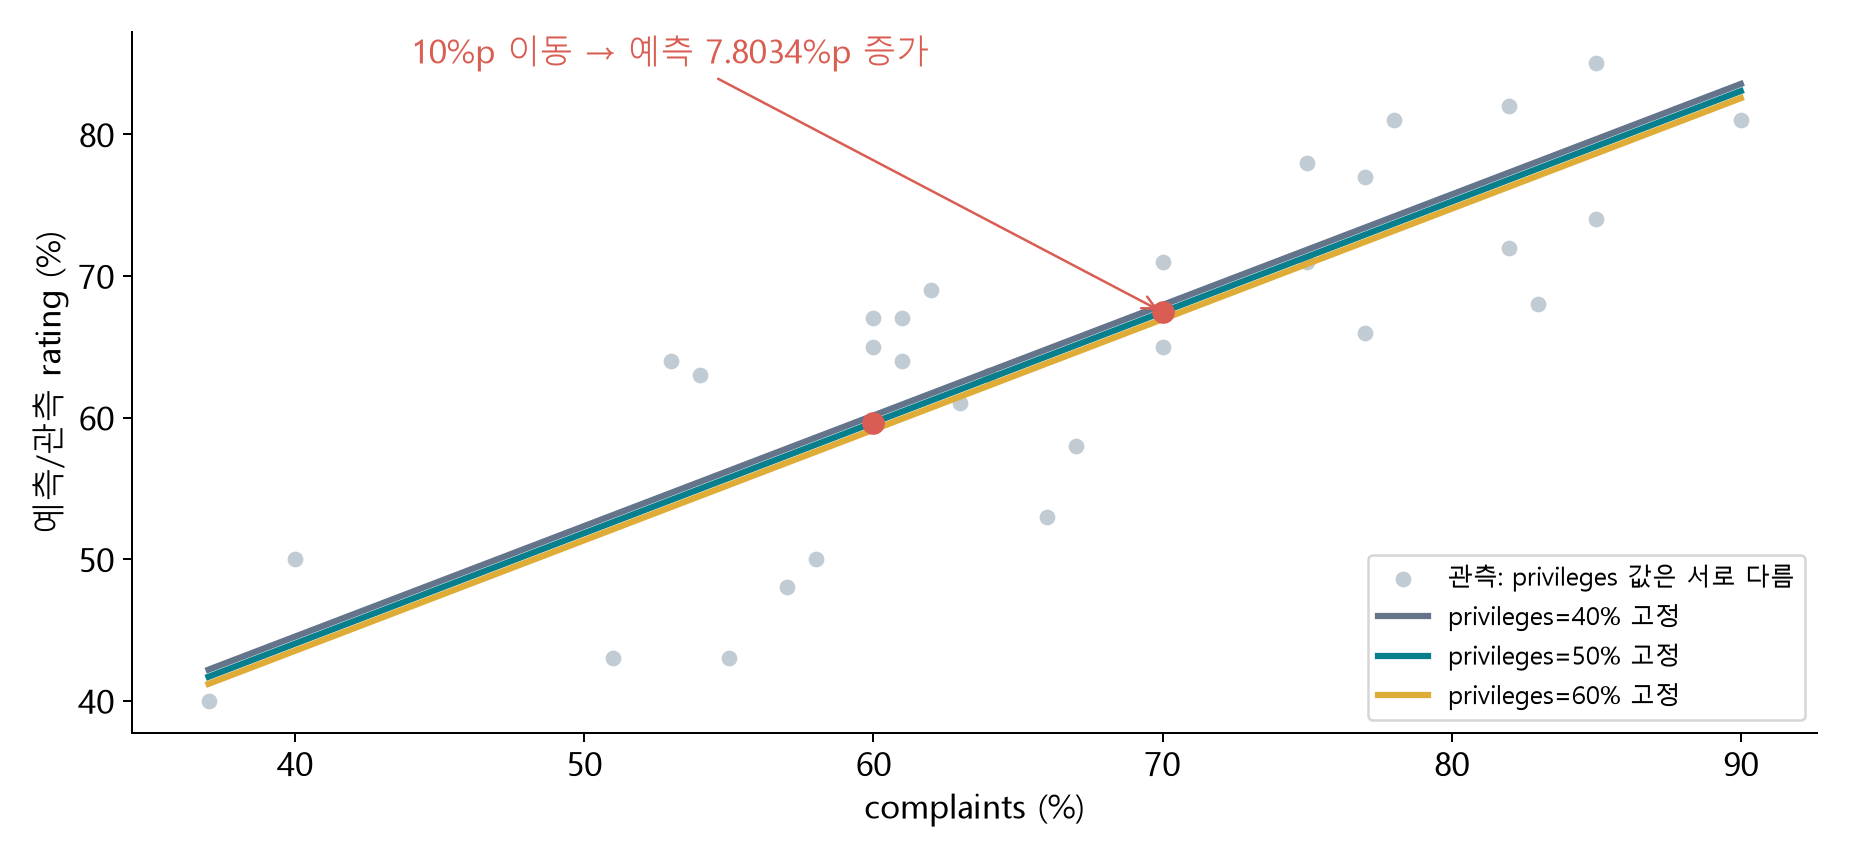

privileges를 고정하고 complaints만 바꾼 예측 단면. 본 수업의 실제 계산으로 만든 그림입니다. [원본](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/course/notion/w05a/assets/m05-fixed-slices.png)

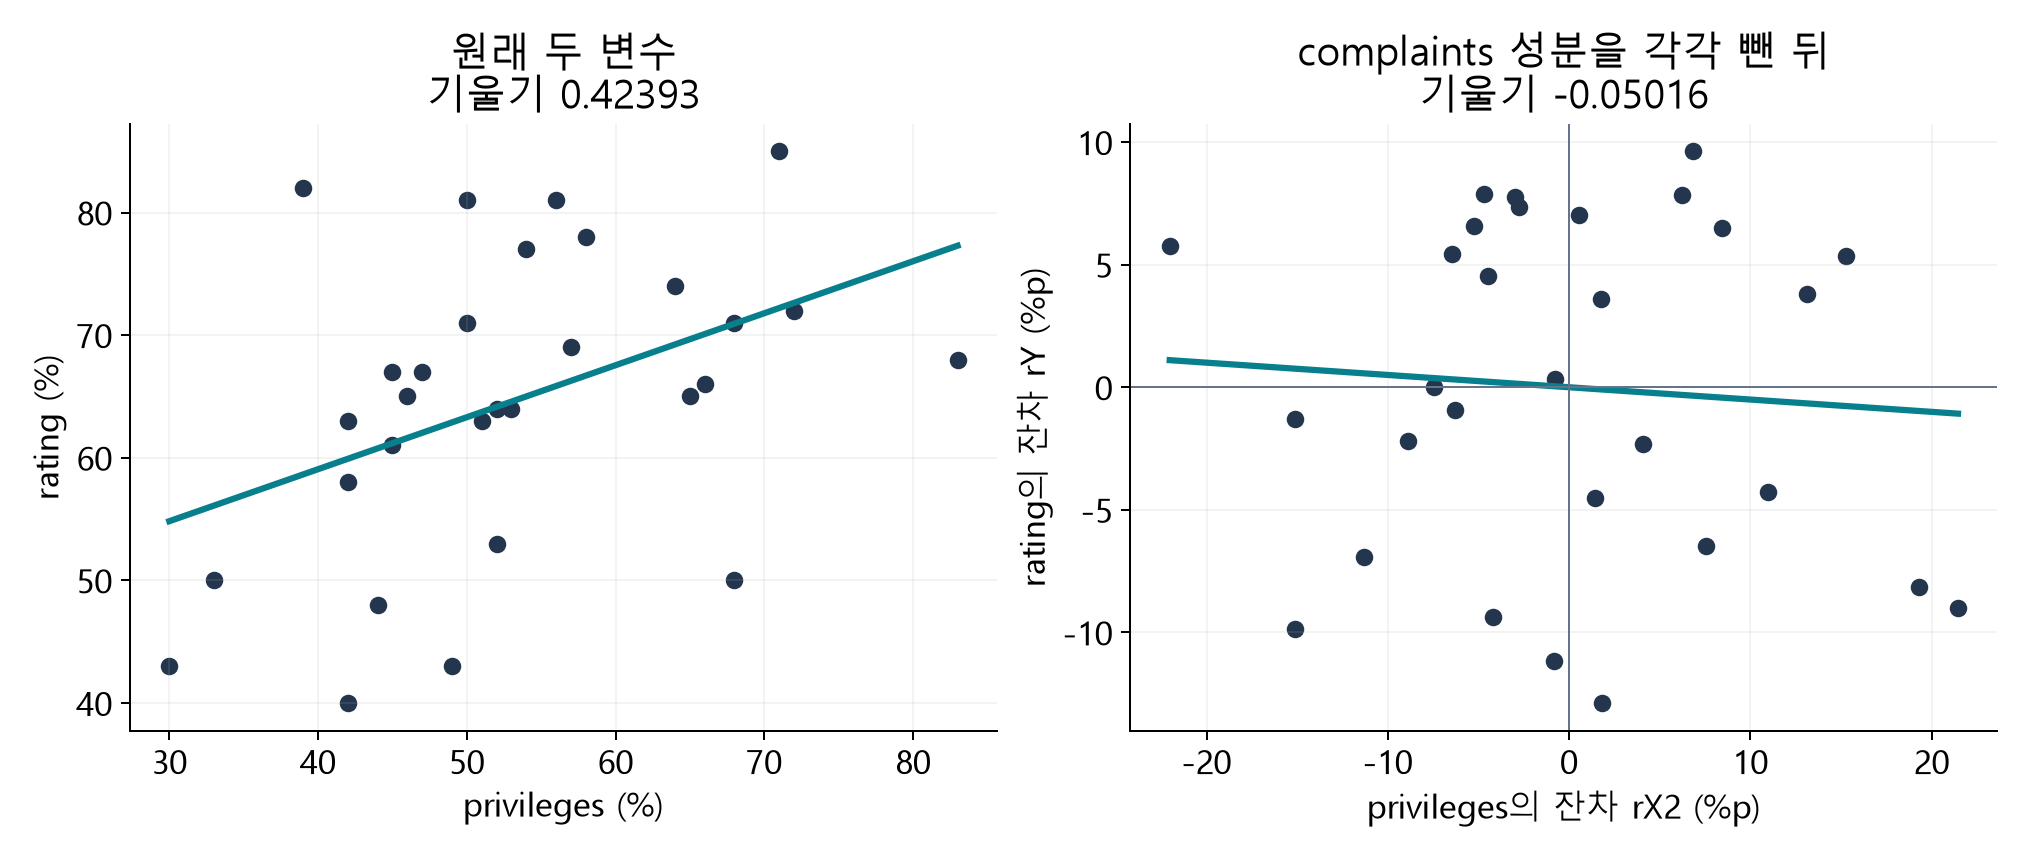

원래 관계와 complaints 성분을 양쪽에서 제거한 잔차 관계. 본 수업의 실제 계산으로 만든 그림입니다. [원본](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/course/notion/w05a/assets/m09-partial-regression.png)

## 1. 준비와 실행 순서

오늘은 **예측 → 실행 → 설명** 순서로 읽습니다. 설치 없는 온라인 R 또는 R 커널 Colab 중 하나만 사용해도 됩니다. 아래 코드는 R입니다. Colab에서 Python 런타임으로 바꾸지 마세요. 처음부터 실행한 뒤 연습 셀을 수정하고, 결과가 왜 바뀌었는지 말로 설명합니다.

다운로드한 R/QMD는 `data` 폴더를 함께 두세요. 웹에서는 Run Code, Colab에서는 셀 왼쪽 실행 버튼을 누릅니다. 아래 공통 코드의 입력·출력·실제 정의 줄은 [API 안내](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-api.md)에 연결되어 있습니다. 학생 연습은 주석으로 남겨 기본 실행을 막지 않습니다. 주석 표시 `#`를 지우고 직접 코드를 완성하세요.

In [ ]:
# 고정 버전 공통 코드: 공개 소스와 동일한 MD5인지 확인합니다.
source_url <- "https://raw.githubusercontent.com/lunalab-ai/regre/2026-fall-w05a/src/mlr-tools.R"
expected_md5 <- "4a5ce6e20ace2451c513cef7a8bcfe2f"
local_candidates <- c("src/mlr-tools.R", "../../src/mlr-tools.R")
existing <- local_candidates[file.exists(local_candidates)]
if (length(existing)) {
  helper_path <- existing[1]
  helper_origin <- "동봉 소스"
} else {
  cache_dir <- file.path(path.expand("~"), ".cache", "regre", "2026-fall-w05a")
  dir.create(cache_dir, recursive=TRUE, showWarnings=FALSE)
  helper_path <- file.path(cache_dir,"mlr-tools.R")
  helper_origin <- if (file.exists(helper_path)) "검증된 캐시" else "고정 버전 최초 다운로드"
  if (!file.exists(helper_path)) download.file(source_url, helper_path, mode="wb", quiet=FALSE)
}
if (unname(tools::md5sum(helper_path)) != expected_md5)
  stop("공통 코드 해시가 다릅니다. 버전과 파일을 확인하세요. 실패를 무시하지 마세요.")
source(helper_path)
cat(helper_origin," | R ",as.character(getRversion()),"
",sep="")

## 4. 감독자 자료의 행·열과 모형

한 행은 직원 한 명이 아니라 **부서 하나**입니다. `str()`와 `head()`로30행·7변수, 단위%를 확인합니다. 두 설명변수의 모형을 기본 R로 적합한 뒤 공통 함수와 비교합니다. [fit_attitude 정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-tools.R#L21)

절편15.3276, complaints기울기0.7803, privileges기울기−0.0502가 나옵니다. 이 값은 R 내장 attitude에서 재현한 결과입니다. 절편은 두 설명변수가0인 조건이라 관측 범위를 벗어납니다.

In [ ]:
d <- datasets::attitude
str(d)
head(d)
fit2 <- lm(rating ~ complaints + privileges, data=d)
coef(fit2)
head(model.matrix(fit2))
fit_helper <- fit_attitude(d)
stopifnot(isTRUE(all.equal(coef(fit2), coef(fit_helper))))

## 5. 같은 조건에서 기울기 읽기

privileges를50%로 고정하고 complaints를60%에서70%로 바꿉니다. 실행 전에 예측 차이를 `10 × 기울기`로 예상하세요. [predict_conditions 정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-tools.R#L89) · [plot_conditional_slice 정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-tools.R#L135)

회색 원자료의 privileges는 서로 다릅니다. 고정 단면 선을 모든 원자료에 대한 단순회귀선으로 읽지 마세요. 10% 변화와10퍼센트포인트 변화도 구분합니다.

In [ ]:
conditions <- predict_conditions(fit2, c(60,70), c(50,50))
conditions
delta <- diff(conditions$rating_hat)
delta
10*coef(fit2)["complaints"]
plot_conditional_slice(fit2, privileges=50)

## L3. 변수를 하나만 바꾸는 코드 고치기

다음 의도는 complaints를60%로 유지하고 privileges만50%에서60%로 바꾸는 것입니다. 주석의 코드가 의도에 맞는지 보고 수정하세요. 힌트: 두 행 사이에 같은 열과 다른 열을 먼저 표시합니다. 출력의 차이에 %p 단위를 붙이세요.

In [ ]:
# L3: 아래는 의도와 다른 코드입니다. 실행 전에 수정하세요.
# wrong <- predict_conditions(fit2, c(60,70), c(50,60))
# diff(wrong$rating_hat)
invisible(NULL)

## 6. 잔차, 최소제곱, 자유도

적합값과 관측값의 차이를 표로 읽습니다. 첫 부서의 실제43, 예측약53.6203, 잔차약−10.6203입니다. 잔차 제곱합은 약1361.8639입니다. 추정한 계수는 절편까지3개이므로 자유도27입니다.

`sigma(fit2)`는 잔차 표준편차이고 `sigma(fit2)^2`가 분산 추정값입니다. R²와 단위가 다릅니다. [ss_decomposition 정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-tools.R#L37)

In [ ]:
residual_table <- data.frame(department=seq_len(nrow(d)),
  actual=d$rating, fitted=fitted(fit2), residual=residuals(fit2))
head(residual_table)
SSE <- sum(resid(fit2)^2)
residual_df <- df.residual(fit2)
sigma2 <- SSE/residual_df
c(SSE=SSE, df=residual_df, sigma2=sigma2, sigma=sqrt(sigma2))
round(ss_decomposition(fit2)$summary, 4)

## L4. 분모를 고치고 제약을 확인하기

`SSE/nrow(d)`를 교재의 오차분산 추정량으로 보고한 코드를 고치세요. 잔차합과 각 설계열·잔차의 내적을 확인하세요. 부동소수점 계산은 정확한0 대신 작은 허용오차로 비교합니다. 힌트: `df.residual()`, `crossprod(model.matrix(fit2),resid(fit2))`.

In [ ]:
# L4: 추정한 계수 수를 반영하여 분모를 수정하세요.
# variance_try <- SSE / nrow(d)
# crossprod(model.matrix(fit2), resid(fit2))
invisible(NULL)

## 7. 두 잔차의 회귀: 같은 조건의 의미

rating과 privileges에서 각각 complaints로 설명되는 선형 성분을 뺍니다. 남은 두 잔차를 회귀하면 다중회귀의 privileges계수와 같은 기울기가 나옵니다. [partial_regression 정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-tools.R#L72)

한쪽만 잔차화한 도표로 ‘두 잔차의 회귀’를 설명하지 않도록 양쪽을 모두 확인합니다. 잔차화는 선형 성분 제거이며 모든 혼란변수를 통제했다는 뜻은 아닙니다.

In [ ]:
partial <- partial_regression(d)
coef(partial$residual_fit)
coef(fit2)["privileges"]
plot(partial$points$rx,partial$points$ry,pch=19,col="#087f8c",
     xlab="Residual privileges",ylab="Residual rating")
abline(partial$residual_fit,col="#d95d52",lwd=2)
abline(h=0,v=0,col="gray70",lty=2)
raw_slope <- coef(lm(rating ~ privileges,data=d))[2]
c(raw=unname(raw_slope), adjusted=partial$slope)

## 8. 같은 행에서 모형 비교

평균/1/2/6변수 모형은 동일한30행을 사용합니다. 모형을 확장하면 학습SSE는 증가하지 않지만 자유도가 줄어 잔차 표준편차는 증가할 수도 있습니다. [compare_attitude_models 정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-tools.R#L58)

여섯 변수 절편은 R 자료에서+10.7871입니다. 교재 식4.11의−10.79와 다르므로 원문 표기를 조용히 바꾸지 않습니다. 두 변수 모형은 교재 반올림과 일치합니다.

In [ ]:
comparison <- compare_attitude_models(d)
comparison
barplot(comparison$SSE,names.arg=comparison$model,col="#087f8c",
        ylab="Training SSE",main="Same response and same rows")

## L5. 재현하고 해석하기

공통 함수 없이 두 잔차 회귀를 직접 구성하고 기울기를 비교하세요. 이어 한 변수→두 변수의 R²와 sigma 변화가 모순인지 설명하세요. 힌트: `resid(lm(...))`, `lm(ry ~ rx)`. 수치 일치는`abs(a-b)<1e-8`로 검사합니다.

In [ ]:
# L5: 같은 complaints로 양쪽을 잔차화하세요.
# ry <- resid(lm(..., data=d))
# rx <- resid(lm(..., data=d))
# coef(lm(ry ~ rx))
invisible(NULL)

## L6. 마지막 활동: 앱의 입력 → 계산 → 출력 연결

[누적 웹 앱 편집기 열기](https://lunalab-ai.github.io/regre/apps/w05a/edit/index.html)

1. **편차와 R²** 탭에서 관측2/4와 평균/회귀 표시를 바꾸고 세 편차를 말합니다. 후보 절편·기울기를 바꾸어 SSE를 읽습니다.
2. **다중회귀** 탭에서 모형을 바꾸고 표의SSE/R²/자유도를 비교합니다. complaints=60, privileges=50에서 시작하여 complaints만70으로 바꿉니다.
3. 편집기의 `L6-OUTPUT`을 찾습니다. 기본 메시지를 **현재 complaints에서10%p 증가했을 때의 예측 차이**가 나오도록 수정하세요. 필요한 계수는`coef(attitude_fit)["complaints"]`입니다. 입력은0–100 범위이며,90%를 넘으면 비교 조건이100%를 넘는 점도 표현하세요.
4. **Re-run app**으로 재실행하고 실제 입력을 바꾸어 문장과 숫자가 함께 갱신되는지 확인합니다. 이 활동은 앱 코드 안에서 합니다. 아래 셀은 앱으로 가는 주소만 출력합니다.

수정한 R 코드는 온라인 R의 다운로드 버튼, Colab은 개인 Drive 사본으로 보관합니다. 서버에 과제가 제출되는 기능은 아닙니다. 다운로드판 Shiny는 app폴더를 작업폴더로 두고`shiny::runApp()`을 실행합니다.

In [ ]:
cat("웹 앱: https://lunalab-ai.github.io/regre/apps/w05a/edit/index.html
")

In [ ]:
stopifnot(nrow(d)==30, ncol(d)==7, df.residual(fit2)==27,
  abs(coef(fit2)["complaints"]-.780343397617943)<1e-8,
  abs(SSE-1361.8638524)<1e-5,
  abs(partial$slope-coef(fit2)["privileges"])<1e-10,
  abs(delta-10*coef(fit2)["complaints"])<1e-10,
  all(diff(comparison$SSE)<=1e-8),
  max(abs(crossprod(model.matrix(fit2),resid(fit2))))<1e-8)
cat("W05A_MULTIPLE_CHECKS_PASSED
")